# Exploratory Data Analysis (EDA)
## Microsoft Cybersecurity Acquisition – Enterprise Risk Register

**Authors:** Honglin Wang, Chuanli Yang, Raymond Twumasi Opoku  
**Course:** ALY 6130 – Risk Management for Analytics  
**Date:** March 2026

---

### Purpose

This notebook performs exploratory data analysis on the 40-item enterprise risk register developed for Microsoft's proposed cybersecurity platform acquisition. The EDA examines the structure, distribution, and relationships among risk scores to inform subsequent qualitative and quantitative assessments.

**References:**
- COSO. (2017). *Enterprise risk management—Integrating with strategy and performance.*
- Hopkin, P. (2018). *Fundamentals of risk management* (5th ed.). Kogan Page.
- PMI. (2021). *A guide to the project management body of knowledge* (7th ed.).

In [1]:
# ============================================================
# Section 1: Environment Setup and Data Loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visual style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

# Load the risk register
FILE_PATH = r'C:\Users\kevin\Desktop\New folder\aly-6130-microsoft--main\aly-6130-microsoft--main\Assignment4\risk_register_updated.xlsx'

df = pd.read_excel(FILE_PATH, sheet_name='Risk Register')

# Clean column names
df.columns = [
    'No', 'Main_Risk_Area', 'Sub_Risk_Question',
    'Likelihood_Score', 'Impact_Score', 'Risk_Level', 'Extra',
    'Risk_Score', 'MC_Mean', 'MC_VaR_95', 'P_High',
    'IW_Composite', 'Warning_Level'
]

# Drop empty extra column
df = df.drop(columns=['Extra'])

# Convert P(High) from string percentage to float
df['P_High'] = df['P_High'].astype(str).str.replace('%', '').astype(float) / 100

# Short labels for risk areas
area_map = {
    'Loss of Cybersecurity Market Share': 'Market Share Loss',
    'Critical Data Breach During Platform Integration': 'Data Breach',
    'Accelerated Enterprise Customer Acquisition Through Bundled Security Offerings': 'Enterprise Acq.'
}
df['Risk_Area_Short'] = df['Main_Risk_Area'].map(area_map)

print(f'Risk register loaded: {df.shape[0]} sub-risks across {df["Main_Risk_Area"].nunique()} risk areas')
df.head()

Risk register loaded: 40 sub-risks across 3 risk areas


,No,Main_Risk_Area,Sub_Risk_Question,Likelihood_Score,Impact_Score,Risk_Level,Risk_Score,MC_Mean,MC_VaR_95,P_High,IW_Composite,Warning_Level,Risk_Area_Short
0,1,Loss of Cybersecurity Market Share,Could specialized competitors offer more innov...,12,7,NaN,84,65.2,86.55,0.984,3.4,YELLOW,Market Share Loss
1,2,Loss of Cybersecurity Market Share,Could the company lose customers because its s...,11,7,NaN,77,65.2,86.55,0.984,3.4,YELLOW,Market Share Loss
2,3,Loss of Cybersecurity Market Share,Could aggressive competitor pricing reduce the...,10,6,NaN,60,65.2,86.55,0.984,3.4,YELLOW,Market Share Loss
3,4,Loss of Cybersecurity Market Share,Could slower product updates weaken the compan...,11,7,NaN,77,65.2,86.55,0.984,3.4,YELLOW,Market Share Loss
4,5,Loss of Cybersecurity Market Share,Could niche competitors attract enterprise cli...,10,8,NaN,80,65.2,86.55,0.984,3.4,YELLOW,Market Share Loss


In [2]:
# ============================================================
# Section 2: Dataset Overview
# ============================================================

print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print(f'Total sub-risks:  {len(df)}')
print(f'Risk areas:       {df["Main_Risk_Area"].nunique()}')
print(f'Data types:\n{df.dtypes}\n')

print('Sub-risks per risk area:')
print(df['Risk_Area_Short'].value_counts().to_string())
print()

print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())
if df.isnull().sum().sum() == 0:
    print('  None — dataset is complete.')

DATASET OVERVIEW
Total sub-risks:  40
Risk areas:       3
Data types:
No                     int64
Main_Risk_Area        object
Sub_Risk_Question     object
Likelihood_Score       int64
Impact_Score           int64
Risk_Level            object
Risk_Score             int64
MC_Mean              float64
MC_VaR_95            float64
P_High               float64
IW_Composite         float64
Warning_Level         object
Risk_Area_Short       object
dtype: object

Sub-risks per risk area:
Risk_Area_Short
Market Share Loss    15
Data Breach          15
Enterprise Acq.      10

Missing values per column:
Risk_Level    35


In [3]:
# ============================================================
# Section 3: Descriptive Statistics
# ============================================================

numeric_cols = ['Likelihood_Score', 'Impact_Score', 'Risk_Score']

print('='*60)
print('DESCRIPTIVE STATISTICS — OVERALL')
print('='*60)
display(df[numeric_cols].describe().round(2))

print('\n' + '='*60)
print('DESCRIPTIVE STATISTICS — BY RISK AREA')
print('='*60)
area_stats = df.groupby('Risk_Area_Short')[numeric_cols].agg(['mean', 'std', 'min', 'max']).round(2)
display(area_stats)

DESCRIPTIVE STATISTICS — OVERALL


,Likelihood_Score,Impact_Score,Risk_Score
count,40.00,40.00,40.00
mean,9.43,7.10,67.68
std,1.34,1.45,18.70
min,7.00,4.00,28.00
25%,8.00,6.00,54.00
50%,9.00,7.00,71.00
75%,10.00,8.00,80.25
max,12.00,9.00,99.00



DESCRIPTIVE STATISTICS — BY RISK AREA


Likelihood_Score               Impact_Score                \
                              mean   std min max         mean   std min max   
Risk_Area_Short                                                               
Data Breach                   9.13  1.30   7  12         8.27  0.88   6   9   
Enterprise Acq.               9.10  1.37   7  11         6.10  1.45   4   8   
Market Share Loss             9.93  1.28   8  12         6.60  1.12   4   8   

                  Risk_Score                 
                        mean    std min max  
Risk_Area_Short                              
Data Breach            75.80  14.93  49  99  
Enterprise Acq.        57.20  21.38  28  88  
Market Share Loss      66.53  17.52  32  96

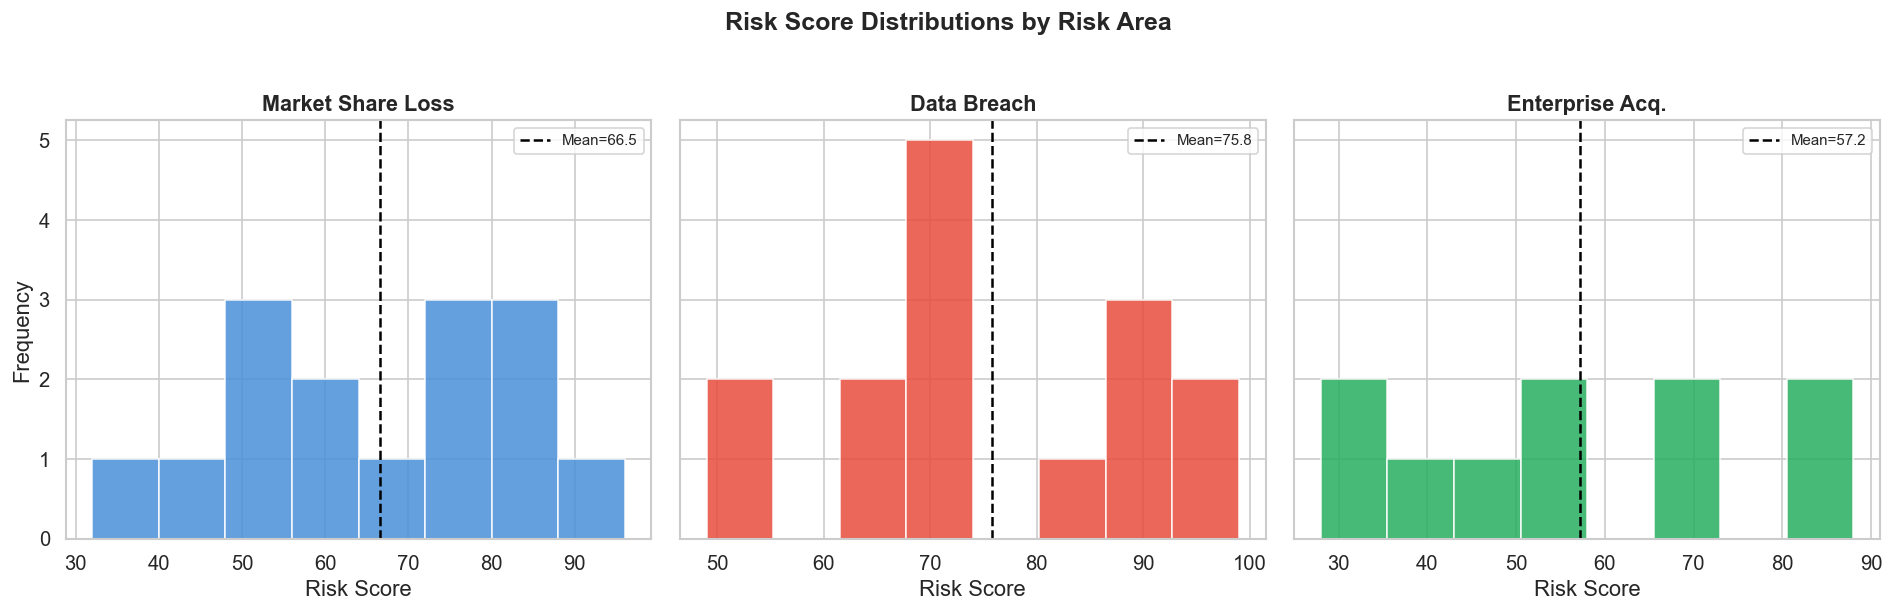

In [4]:
# ============================================================
# Section 4: Risk Score Distribution by Risk Area
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

colors = {'Market Share Loss': '#4A90D9', 'Data Breach': '#E74C3C', 'Enterprise Acq.': '#27AE60'}
areas = ['Market Share Loss', 'Data Breach', 'Enterprise Acq.']

for ax, area in zip(axes, areas):
    subset = df[df['Risk_Area_Short'] == area]['Risk_Score']
    ax.hist(subset, bins=8, color=colors[area], edgecolor='white', alpha=0.85)
    ax.axvline(subset.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean={subset.mean():.1f}')
    ax.set_title(area, fontsize=13, fontweight='bold')
    ax.set_xlabel('Risk Score')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Frequency')
fig.suptitle('Risk Score Distributions by Risk Area', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

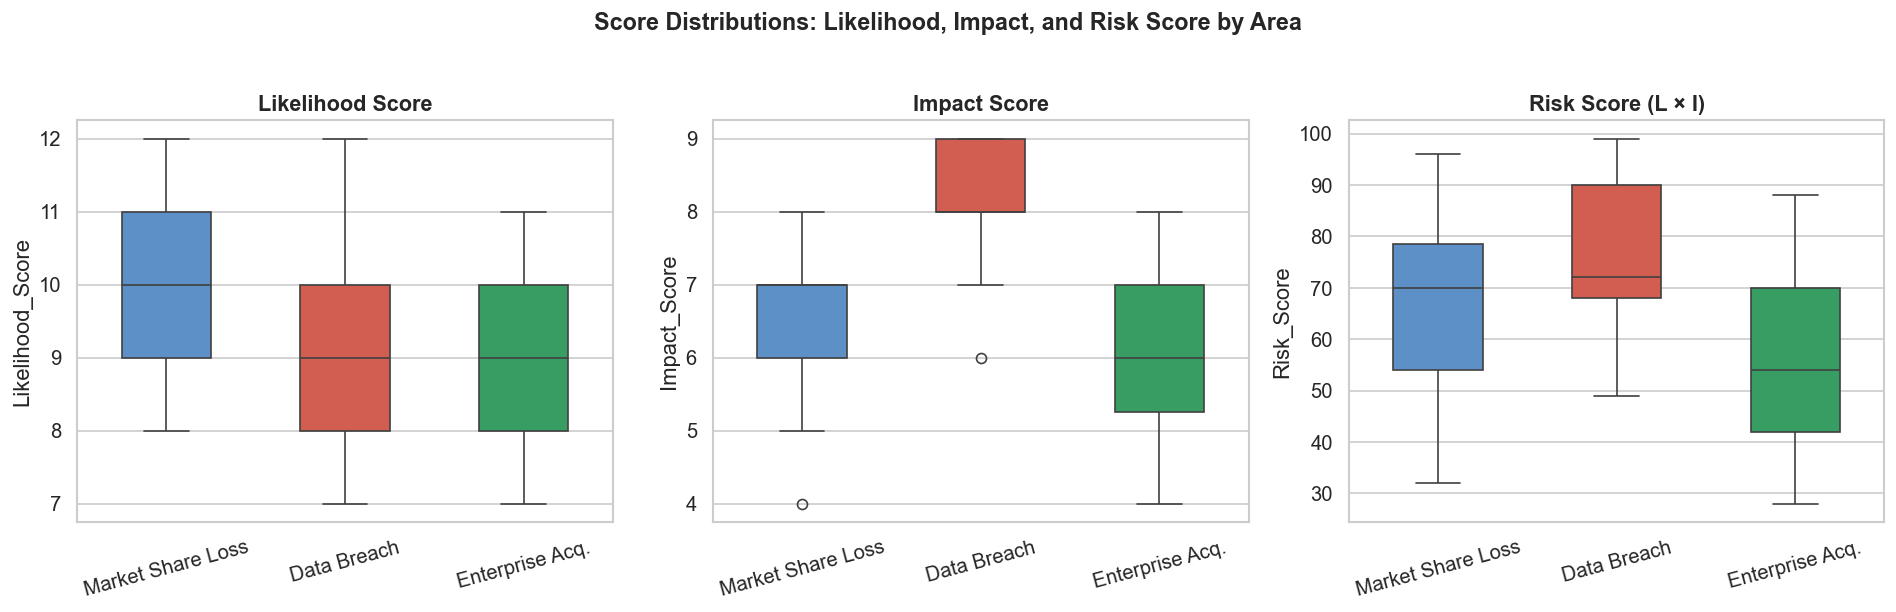

In [5]:
# ============================================================
# Section 5: Box Plot Comparison Across Risk Areas
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes,
    ['Likelihood_Score', 'Impact_Score', 'Risk_Score'],
    ['Likelihood Score', 'Impact Score', 'Risk Score (L × I)']):
    
    sns.boxplot(data=df, x='Risk_Area_Short', y=col, ax=ax,
                order=areas, palette=colors, width=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Score Distributions: Likelihood, Impact, and Risk Score by Area',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

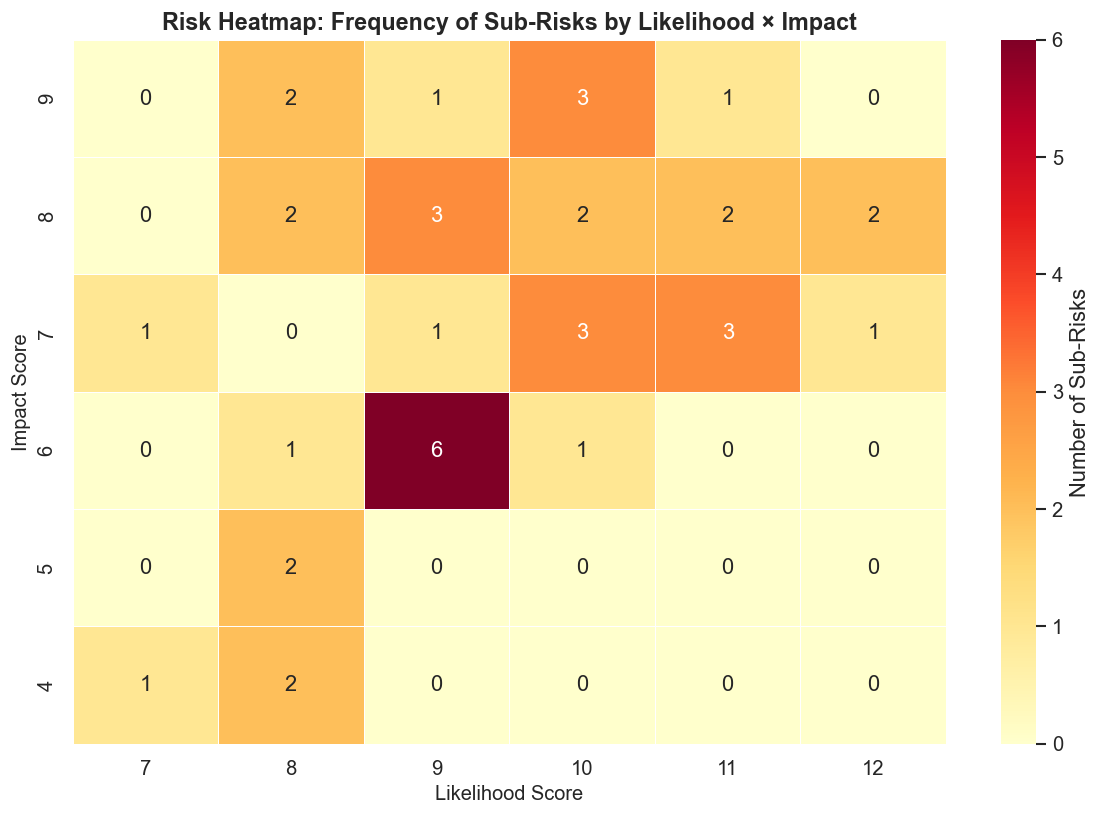


Interpretation: The upper-right quadrant (high likelihood, high impact)
concentrates the most critical risks, primarily from the Data Breach area.
The densest cluster at L=9, I=6 represents moderate-impact competitive risks.


In [6]:
# ============================================================
# Section 6: Risk Heatmap (Likelihood × Impact)
# ============================================================

# Create pivot table counting risks at each (Likelihood, Impact) coordinate
heatmap_data = df.pivot_table(
    index='Impact_Score', columns='Likelihood_Score',
    values='No', aggfunc='count', fill_value=0
)
# Sort index descending so high impact is at top
heatmap_data = heatmap_data.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Number of Sub-Risks'},
            ax=ax)
ax.set_xlabel('Likelihood Score', fontsize=12)
ax.set_ylabel('Impact Score', fontsize=12)
ax.set_title('Risk Heatmap: Frequency of Sub-Risks by Likelihood × Impact',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterpretation: The upper-right quadrant (high likelihood, high impact)')
print('concentrates the most critical risks, primarily from the Data Breach area.')
print('The densest cluster at L=9, I=6 represents moderate-impact competitive risks.')

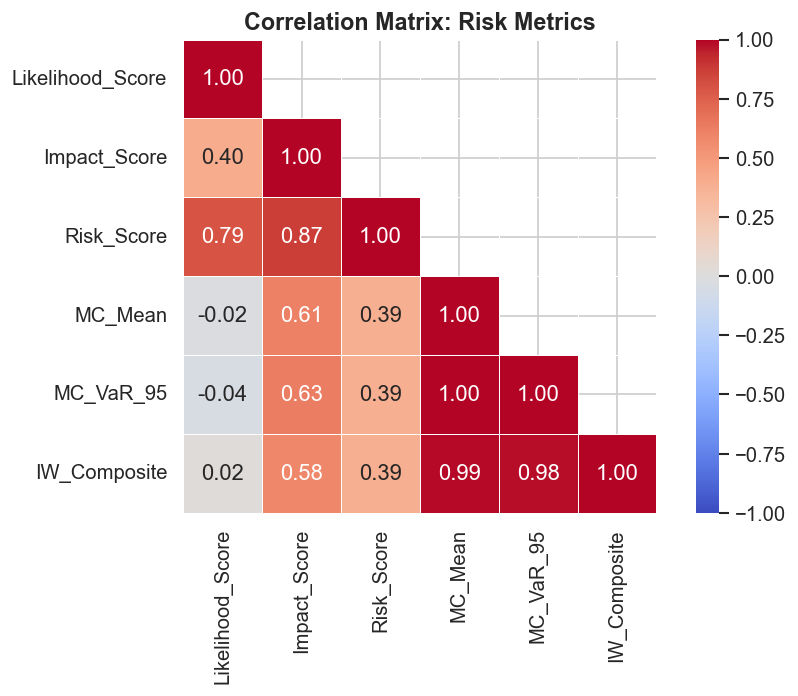


Key observations:
- Likelihood and Impact scores jointly drive Risk Score (by construction).
- MC Mean and MC VaR are strongly correlated with the I&W composite,
  confirming that the Monte Carlo outputs align with indicator-based warnings.


In [7]:
# ============================================================
# Section 7: Correlation Analysis
# ============================================================

corr_cols = ['Likelihood_Score', 'Impact_Score', 'Risk_Score', 'MC_Mean', 'MC_VaR_95', 'IW_Composite']
corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Matrix: Risk Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey observations:')
print('- Likelihood and Impact scores jointly drive Risk Score (by construction).')
print('- MC Mean and MC VaR are strongly correlated with the I&W composite,')
print('  confirming that the Monte Carlo outputs align with indicator-based warnings.')

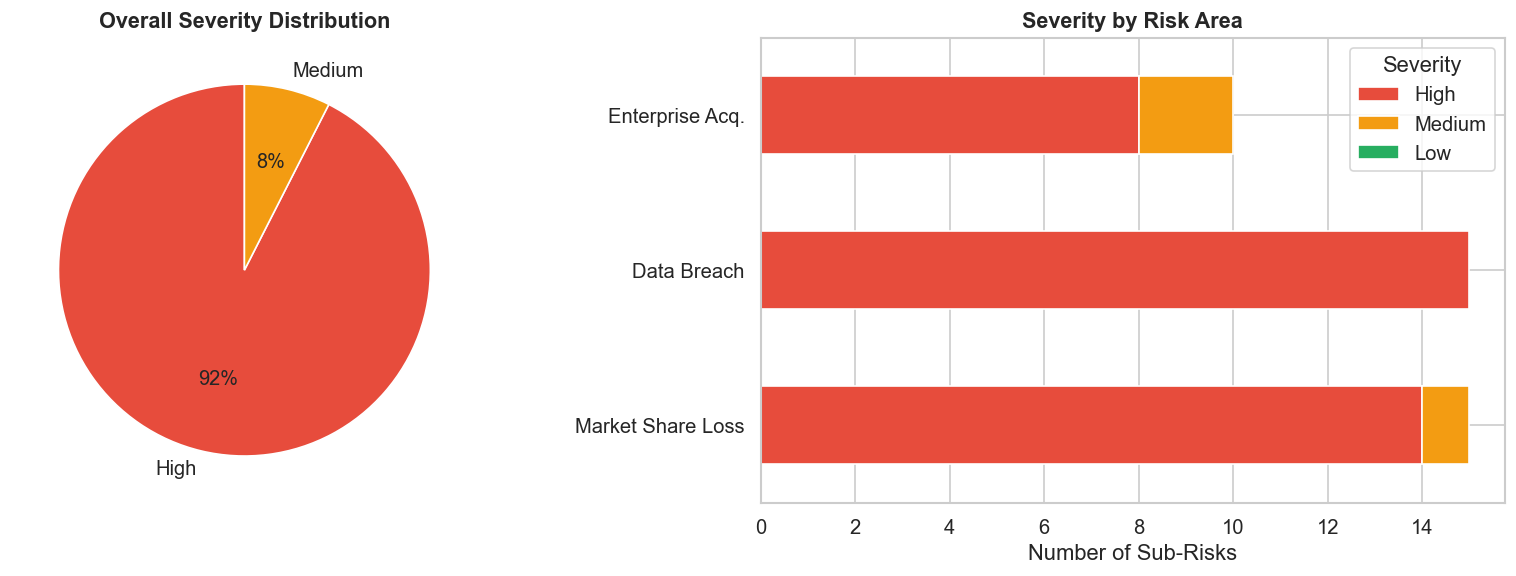


Severity counts: {'High': 37, 'Medium': 3}
The overwhelming majority of risks are High severity, reflecting
the elevated threat environment of a major cybersecurity acquisition (COSO, 2017).


In [8]:
# ============================================================
# Section 8: Severity Classification Analysis
# ============================================================

# Classify severity: High >= 40, Medium 15-39, Low < 15
def classify_severity(score):
    if score >= 40:
        return 'High'
    elif score >= 15:
        return 'Medium'
    else:
        return 'Low'

df['Severity'] = df['Risk_Score'].apply(classify_severity)

# Overall severity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — overall
sev_counts = df['Severity'].value_counts()
sev_colors = {'High': '#E74C3C', 'Medium': '#F39C12', 'Low': '#27AE60'}
axes[0].pie(sev_counts, labels=sev_counts.index, autopct='%1.0f%%',
            colors=[sev_colors[s] for s in sev_counts.index],
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Overall Severity Distribution', fontsize=13, fontweight='bold')

# Stacked bar — by area
cross = pd.crosstab(df['Risk_Area_Short'], df['Severity'])
cross = cross.reindex(columns=['High', 'Medium', 'Low'], fill_value=0)
cross.loc[areas].plot(kind='barh', stacked=True, ax=axes[1],
                      color=[sev_colors['High'], sev_colors['Medium'], sev_colors['Low']],
                      edgecolor='white')
axes[1].set_title('Severity by Risk Area', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Sub-Risks')
axes[1].set_ylabel('')
axes[1].legend(title='Severity')

plt.tight_layout()
plt.show()

print(f'\nSeverity counts: {sev_counts.to_dict()}')
print('The overwhelming majority of risks are High severity, reflecting')
print('the elevated threat environment of a major cybersecurity acquisition (COSO, 2017).')

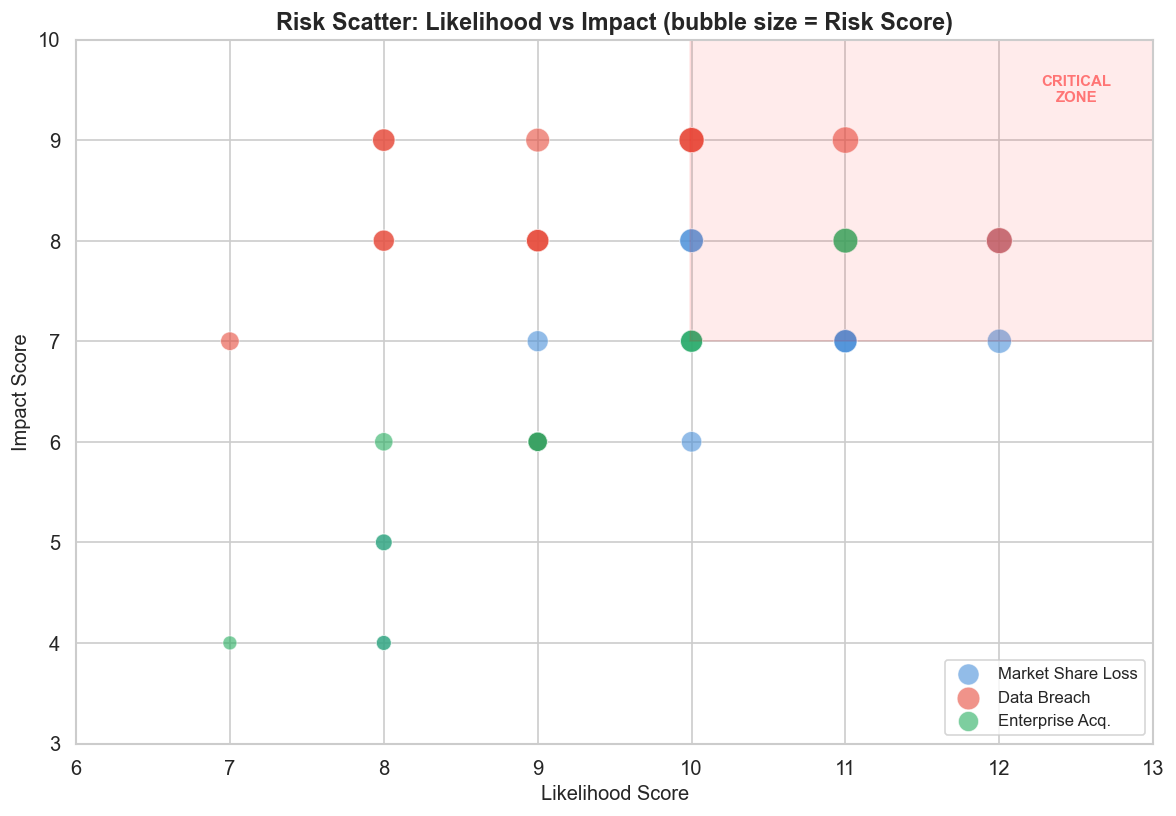


Data Breach risks cluster in the upper-right (high L, high I) region.
Enterprise Acquisition risks are more dispersed with lower impact scores.


In [9]:
# ============================================================
# Section 9: Scatter Plot — Likelihood vs Impact
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

for area in areas:
    subset = df[df['Risk_Area_Short'] == area]
    ax.scatter(subset['Likelihood_Score'], subset['Impact_Score'],
              s=subset['Risk_Score'] * 2.5, alpha=0.6,
              color=colors[area], label=area, edgecolors='white', linewidth=0.5)

ax.set_xlabel('Likelihood Score', fontsize=12)
ax.set_ylabel('Impact Score', fontsize=12)
ax.set_title('Risk Scatter: Likelihood vs Impact (bubble size = Risk Score)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(6, 13)
ax.set_ylim(3, 10)

# Add risk zone shading
ax.axhspan(7, 10, xmin=0.57, xmax=1.0, alpha=0.08, color='red', label='_nolegend_')
ax.text(12.5, 9.5, 'CRITICAL\nZONE', ha='center', va='center',
        fontsize=9, color='red', alpha=0.5, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nData Breach risks cluster in the upper-right (high L, high I) region.')
print('Enterprise Acquisition risks are more dispersed with lower impact scores.')

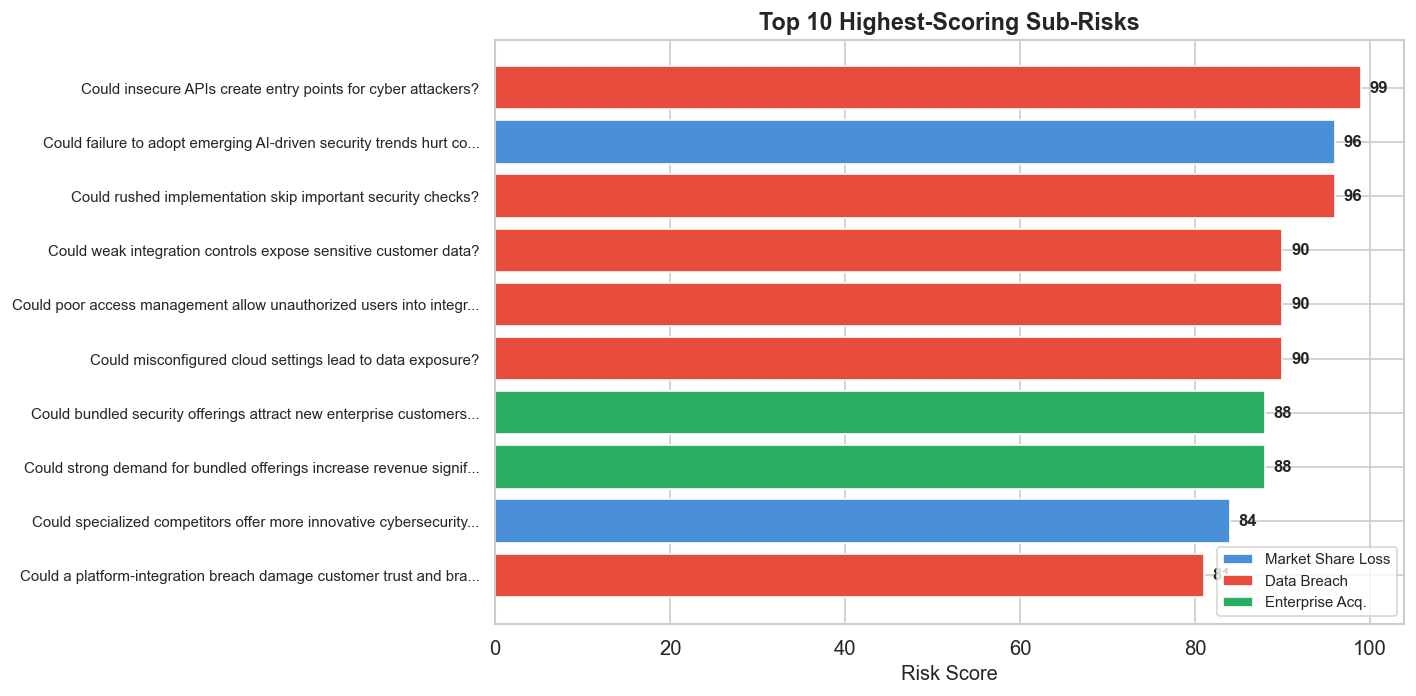


The top risks are dominated by Data Breach and Market Share Loss sub-risks.
Insecure APIs (score=99) and rushed implementation (score=96) are the highest.


In [10]:
# ============================================================
# Section 10: Top 10 Highest-Scoring Sub-Risks
# ============================================================

top10 = df.nlargest(10, 'Risk_Score')[['No', 'Risk_Area_Short', 'Sub_Risk_Question',
                                        'Likelihood_Score', 'Impact_Score', 'Risk_Score']]

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = [colors[a] for a in top10['Risk_Area_Short']]
bars = ax.barh(range(len(top10)), top10['Risk_Score'], color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([q[:65] + '...' if len(q) > 65 else q for q in top10['Sub_Risk_Question']],
                   fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Risk Score', fontsize=12)
ax.set_title('Top 10 Highest-Scoring Sub-Risks', fontsize=14, fontweight='bold')

# Add value labels
for bar, score in zip(bars, top10['Risk_Score']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{score}', va='center', fontsize=10, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[a], label=a) for a in areas]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print('\nThe top risks are dominated by Data Breach and Market Share Loss sub-risks.')
print('Insecure APIs (score=99) and rushed implementation (score=96) are the highest.')

In [11]:
# ============================================================
# Section 11: Warning Level Summary
# ============================================================

print('='*60)
print('I&W WARNING LEVELS BY RISK AREA')
print('='*60)

warning_summary = df.groupby('Risk_Area_Short').agg(
    Count=('No', 'count'),
    Avg_Risk_Score=('Risk_Score', 'mean'),
    MC_Mean=('MC_Mean', 'first'),
    MC_VaR_95=('MC_VaR_95', 'first'),
    P_High=('P_High', 'first'),
    IW_Composite=('IW_Composite', 'first'),
    Warning=('Warning_Level', 'first')
).round(2)

display(warning_summary.loc[areas])

print('\nConclusion:')
print('- Data Breach: RED warning — immediate intervention required.')
print('- Market Share Loss: YELLOW — heightened monitoring needed.')
print('- Enterprise Acquisition: GREEN — favorable, but 86.5% P(High) warrants vigilance.')

I&W WARNING LEVELS BY RISK AREA


,Count,Avg_Risk_Score,MC_Mean,MC_VaR_95,P_High,IW_Composite,Warning
Risk_Area_Short,,,,,,,
Market Share Loss,15,66.53,65.20,86.55,0.98,3.4,YELLOW
Data Breach,15,75.80,74.58,95.35,1.00,4.0,RED
Enterprise Acq.,10,57.20,55.37,79.01,0.86,2.4,GREEN



Conclusion:
- Data Breach: RED warning — immediate intervention required.
- Market Share Loss: YELLOW — heightened monitoring needed.
- Enterprise Acquisition: GREEN — favorable, but 86.5% P(High) warrants vigilance.


In [12]:
# ============================================================
# Section 12: EDA Summary and Key Findings
# ============================================================

print('='*60)
print('EDA SUMMARY — KEY FINDINGS')
print('='*60)
print('''
1. DATASET COMPOSITION: 40 sub-risks across 3 risk areas
   (15 Market Share, 15 Data Breach, 10 Enterprise Acquisition).

2. SEVERITY PROFILE: 37/40 (92.5%) classified as High severity.
   No Low-severity risks exist — consistent with the elevated
   threat environment of a cybersecurity acquisition (COSO, 2017).

3. DATA BREACH IS THE CRITICAL RISK AREA:
   - Highest mean risk score (75.8)
   - Highest impact scores (mean = 8.2)
   - RED I&W warning level (composite = 4.00)
   - 100% probability of High classification under Monte Carlo

4. MARKET SHARE LOSS IS ELEVATED:
   - Mean risk score = 66.5 (YELLOW warning)
   - 98.4% P(High) — near-certain High classification
   - Driven by competitive dynamics and innovation speed gaps

5. ENTERPRISE ACQUISITION IS THE MOST FAVORABLE:
   - GREEN warning (composite = 2.40)
   - But 86.5% P(High) means underlying volatility is real
   - Contains the only Medium-severity sub-risks

6. RISK CONCENTRATION: The heatmap shows clustering at
   (L=9-10, I=6-7) and (L=10-12, I=8-9), indicating a
   bimodal risk profile that warrants both broad monitoring
   and targeted intervention for extreme risks.

These findings directly inform the qualitative and quantitative
assessments that follow in the analysis pipeline.
''')

EDA SUMMARY — KEY FINDINGS

1. DATASET COMPOSITION: 40 sub-risks across 3 risk areas
   (15 Market Share, 15 Data Breach, 10 Enterprise Acquisition).

2. SEVERITY PROFILE: 37/40 (92.5%) classified as High severity.
   No Low-severity risks exist — consistent with the elevated
   threat environment of a cybersecurity acquisition (COSO, 2017).

3. DATA BREACH IS THE CRITICAL RISK AREA:
   - Highest mean risk score (75.8)
   - Highest impact scores (mean = 8.2)
   - RED I&W warning level (composite = 4.00)
   - 100% probability of High classification under Monte Carlo

4. MARKET SHARE LOSS IS ELEVATED:
   - Mean risk score = 66.5 (YELLOW warning)
   - 98.4% P(High) — near-certain High classification
   - Driven by competitive dynamics and innovation speed gaps

5. ENTERPRISE ACQUISITION IS THE MOST FAVORABLE:
   - GREEN warning (composite = 2.40)
   - But 86.5% P(High) means underlying volatility is real
   - Contains the only Medium-severity sub-risks

6. RISK CONCENTRATION: The heatmap 